# Task 6 - Data Preprocessing & Feature Engineering
This notebook covers data cleaning, outlier detection, encoding, scaling, feature engineering, and mandatory preprocessing tasks.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer


## Practical 1 - Student Data Cleaning

In [3]:
student = pd.DataFrame({
    'Name':['Amit','Neha','Rahul','Rahul','Priya'],
    'Marks':[75,np.nan,88,88,65],
    'Attendance':[90,95,80,80,np.nan]
})

print(student)
print(student.isnull().sum())

student['Marks'].fillna(student['Marks'].mean(), inplace=True)
student['Attendance'].fillna(student['Attendance'].median(), inplace=True)

student = student.drop_duplicates()

student.to_csv('student_cleaned.csv', index=False)

student


    Name  Marks  Attendance
0   Amit   75.0        90.0
1   Neha    NaN        95.0
2  Rahul   88.0        80.0
3  Rahul   88.0        80.0
4  Priya   65.0         NaN
Name          0
Marks         1
Attendance    1
dtype: int64


C:\Users\anujr\AppData\Local\Temp\ipykernel_20156\1802498777.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  student['Marks'].fillna(student['Marks'].mean(), inplace=True)
C:\Users\anujr\AppData\Local\Temp\ipykernel_20156\1802498777.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

,Name,Marks,Attendance
0,Amit,75.0,90.0
1,Neha,79.0,95.0
2,Rahul,88.0,80.0
4,Priya,65.0,85.0


## Practical 2 - Employee Salary Outlier Detection

  Employee  Salary
2        C  450000
Average Before: 118600.0
Average After: 35750.0


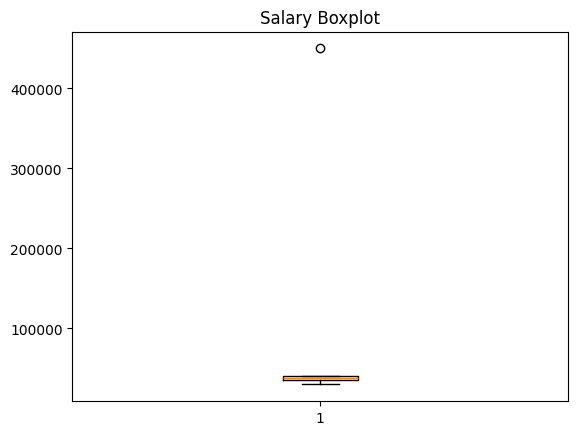

In [4]:
salary = pd.DataFrame({
    'Employee':['A','B','C','D','E'],
    'Salary':[30000,35000,450000,40000,38000]
})

Q1 = salary['Salary'].quantile(0.25)
Q3 = salary['Salary'].quantile(0.75)
IQR = Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

outliers = salary[(salary['Salary']<lower)|(salary['Salary']>upper)]

print(outliers)

clean_salary = salary[(salary['Salary']>=lower)&(salary['Salary']<=upper)]

print("Average Before:",salary['Salary'].mean())
print("Average After:",clean_salary['Salary'].mean())

plt.boxplot(salary['Salary'])
plt.title("Salary Boxplot")
plt.show()


## Practical 3 - Encoding

In [5]:
customer = pd.DataFrame({
    'Customer':['Amit','Neha','Rahul'],
    'Gender':['Male','Female','Male'],
    'Membership':['Gold','Silver','Platinum']
})

le = LabelEncoder()

customer['Gender_Label'] = le.fit_transform(customer['Gender'])

onehot = pd.get_dummies(customer[['Membership']])

print(customer)
print(onehot)


  Customer  Gender Membership  Gender_Label
0     Amit    Male       Gold             1
1     Neha  Female     Silver             0
2    Rahul    Male   Platinum             1
   Membership_Gold  Membership_Platinum  Membership_Silver
0             True                False              False
1            False                False               True
2            False                 True              False


## Practical 4 - Feature Scaling

In [6]:
house = pd.DataFrame({
    'Area':[1200,1800,2400],
    'Income':[50000,80000,120000],
    'Price':[45,72,95]
})

std = StandardScaler()
mm = MinMaxScaler()

house_std = house.copy()
house_std[['Area','Income']] = std.fit_transform(house[['Area','Income']])

house_mm = house.copy()
house_mm[['Area','Income']] = mm.fit_transform(house[['Area','Income']])

print(house)
print(house_std)
print(house_mm)


   Area  Income  Price
0  1200   50000     45
1  1800   80000     72
2  2400  120000     95
       Area    Income  Price
0 -1.224745 -1.162476     45
1  0.000000 -0.116248     72
2  1.224745  1.278724     95
   Area    Income  Price
0   0.0  0.000000     45
1   0.5  0.428571     72
2   1.0  1.000000     95


## Practical 5 - Feature Engineering

In [7]:
sales = pd.DataFrame({
    'Product':['Laptop','Mobile'],
    'Quantity':[2,3],
    'Price':[50000,20000]
})

sales['Revenue'] = sales['Quantity']*sales['Price']
sales['Discounted Price'] = sales['Price']*0.90
sales['GST Amount'] = sales['Revenue']*0.18
sales['Final Amount'] = sales['Revenue']+sales['GST Amount']

sales


,Product,Quantity,Price,Revenue,Discounted Price,GST Amount,Final Amount
0,Laptop,2,50000,100000,45000.0,18000.0,118000.0
1,Mobile,3,20000,60000,18000.0,10800.0,70800.0


## Mandatory Task 1 - Customer Data Cleaning & Feature Engineering

In [8]:
customer = pd.DataFrame({
'CustomerID':[101,102,103,103,104,105],
'Name':['Amit','Neha','Rahul','Rahul','Priya','Jay'],
'Gender':['Male','Female','Male','Male','Female','Male'],
'City':['Ahmedabad','Surat','Ahmedabad','Ahmedabad','Vadodara','Rajkot'],
'Age':[25,np.nan,30,30,27,80],
'Income':[45000,55000,120000,120000,50000,900000],
'PurchaseAmount':[1200,2200,6500,6500,np.nan,50000]
})

customer['Age'].fillna(customer['Age'].median(), inplace=True)
customer['PurchaseAmount'].fillna(customer['PurchaseAmount'].mean(), inplace=True)
customer = customer.drop_duplicates()

Q1 = customer['Income'].quantile(0.25)
Q3 = customer['Income'].quantile(0.75)
IQR = Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

customer['Income_Outlier'] = ((customer['Income']<lower)|(customer['Income']>upper))

le = LabelEncoder()
customer['Gender'] = le.fit_transform(customer['Gender'])

customer = pd.get_dummies(customer, columns=['City'])

scaler = StandardScaler()
customer[['Income','PurchaseAmount']] = scaler.fit_transform(customer[['Income','PurchaseAmount']])

def spend(x):
    if x>5000:
        return 'High'
    elif x>=2000:
        return 'Medium'
    return 'Low'

customer['SpendingCategory'] = customer['PurchaseAmount'].apply(lambda x:'Scaled')

customer.to_csv("customer_data_cleaned.csv", index=False)

customer


C:\Users\anujr\AppData\Local\Temp\ipykernel_20156\2422851681.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customer['Age'].fillna(customer['Age'].median(), inplace=True)
C:\Users\anujr\AppData\Local\Temp\ipykernel_20156\2422851681.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

,CustomerID,Name,Gender,Age,Income,PurchaseAmount,Income_Outlier,City_Ahmedabad,City_Rajkot,City_Surat,City_Vadodara,SpendingCategory
0,101,Amit,1,25.0,-0.565671,-0.738771,False,True,False,False,False,Scaled
1,102,Neha,0,30.0,-0.535741,-0.683787,False,False,False,True,False,Scaled
2,103,Rahul,1,30.0,-0.341198,-0.447354,False,True,False,False,False,Scaled
4,104,Priya,0,27.0,-0.550706,-0.074559,False,False,False,False,True,Scaled
5,105,Jay,1,80.0,1.993315,1.944471,True,False,True,False,False,Scaled


## Mandatory Task 2 - Online Retail Data Preparation Pipeline

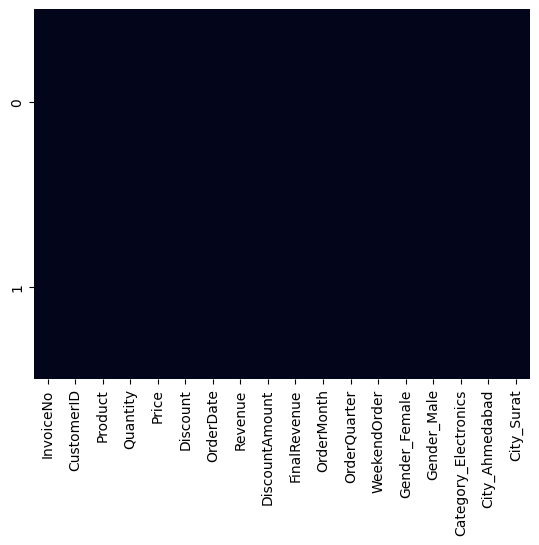

,InvoiceNo,CustomerID,Product,Quantity,Price,Discount,OrderDate,Revenue,DiscountAmount,FinalRevenue,OrderMonth,OrderQuarter,WeekendOrder,Gender_Female,Gender_Male,Category_Electronics,City_Ahmedabad,City_Surat
0,1001,C101,Laptop,0.0,1.0,5,2026-01-10,1.0,2500.0,47500.0,1,1,True,False,True,True,True,False
1,1002,C102,Mobile,1.0,0.0,10,2026-01-12,0.0,4000.0,36000.0,1,1,False,True,False,True,False,True


In [9]:
retail = pd.DataFrame({
'InvoiceNo':[1001,1002],
'CustomerID':['C101','C102'],
'Gender':['Male','Female'],
'City':['Ahmedabad','Surat'],
'Product':['Laptop','Mobile'],
'Category':['Electronics','Electronics'],
'Quantity':[1,2],
'Price':[50000,20000],
'Discount':[5,10],
'OrderDate':['2026-01-10','2026-01-12']
})

retail['OrderDate']=pd.to_datetime(retail['OrderDate'])

retail['Revenue']=retail['Quantity']*retail['Price']
retail['DiscountAmount']=retail['Revenue']*retail['Discount']/100
retail['FinalRevenue']=retail['Revenue']-retail['DiscountAmount']
retail['OrderMonth']=retail['OrderDate'].dt.month
retail['OrderQuarter']=retail['OrderDate'].dt.quarter
retail['WeekendOrder']=retail['OrderDate'].dt.dayofweek>=5

retail = pd.get_dummies(retail, columns=['Gender','Category','City'])

scale = MinMaxScaler()
retail[['Quantity','Price','Revenue']] = scale.fit_transform(retail[['Quantity','Price','Revenue']])

sns.heatmap(retail.isnull(), cbar=False)
plt.show()

retail.to_csv("online_retail_cleaned.csv", index=False)
retail.to_csv("online_retail_ml_ready.csv", index=False)

retail.head()
